# PatchTST Definitivo — Optuna (50 épocas/trial) + pronóstico de El Niño

PatchTST es una arquitectura Transformer más simple que TFT (sin componentes LSTM/gating internos) — soporta covariables nativamente vía `num_feat_dynamic_real`, y al ser más liviana tiene mejor chance de correr en MPS (GPU de Apple) sin el problema de compatibilidad float64 que forzó a TFT a usar CPU.

**Aviso de tiempo:** 25 trials × 50 épocas + reentrenamiento final. Si MPS funciona, debería ser notablemente más rápido que el intento con TFT en CPU; si no, cae automáticamente a CPU sin romper la ejecución.

In [4]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'  # antes de importar torch

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, median_absolute_error, max_error
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.patch_tst import PatchTSTEstimator
import optuna
import joblib
import torch

print(f"MPS disponible: {torch.backends.mps.is_available()}")

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

FREQ = "D"
PASOS = 30

train_data = df[df.index < '2025-08-01']
test_data = df[(df.index >= '2025-08-01') & (df.index <= '2026-07-31')]

print(f"Train: {len(train_data)} días")
print(f"Test: {len(test_data)} días")

MPS disponible: True
Train: 4595 días
Test: 365 días


## Covariable RONI futura (proyección de El Niño)

**⚠️ VERIFICAR MANUALMENTE:** actualizado al reporte del 17-ago-2026 (RONI=1.0 en MJJ 2026, categoría "muy fuerte" declarada, >90% probabilidad). Fuente: https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/lanina/enso_evolution-status-fcsts-web.pdf

In [5]:
RONI_ULTIMO_OBSERVADO = 1.0
CATEGORIA_OUTLOOK = 'muy_fuerte'
PUNTOS_MEDIOS_CATEGORIA = {'debil': 0.7, 'moderado': 1.2, 'fuerte': 1.7, 'muy_fuerte': 2.3}
roni_objetivo = PUNTOS_MEDIOS_CATEGORIA[CATEGORIA_OUTLOOK]

fechas_futuras = pd.date_range('2026-08-01', '2026-08-30', freq='D')

roni_futuro_serie = pd.Series(
    np.linspace(RONI_ULTIMO_OBSERVADO, roni_objetivo, len(fechas_futuras)),
    index=fechas_futuras
)
print("RONI proyectado:")
print(roni_futuro_serie)

RONI proyectado:
2026-08-01    1.000000
2026-08-02    1.044828
2026-08-03    1.089655
2026-08-04    1.134483
2026-08-05    1.179310
2026-08-06    1.224138
2026-08-07    1.268966
2026-08-08    1.313793
2026-08-09    1.358621
2026-08-10    1.403448
2026-08-11    1.448276
2026-08-12    1.493103
2026-08-13    1.537931
2026-08-14    1.582759
2026-08-15    1.627586
2026-08-16    1.672414
2026-08-17    1.717241
2026-08-18    1.762069
2026-08-19    1.806897
2026-08-20    1.851724
2026-08-21    1.896552
2026-08-22    1.941379
2026-08-23    1.986207
2026-08-24    2.031034
2026-08-25    2.075862
2026-08-26    2.120690
2026-08-27    2.165517
2026-08-28    2.210345
2026-08-29    2.255172
2026-08-30    2.300000
Freq: D, dtype: float64


## Datasets con covariables (gen_termica, ONI, aportes_energia_gwh)

In [6]:
covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

scaler_cov = StandardScaler()
scaler_cov.fit(train_data[covariables])

df_scaled = df.copy()
df_scaled[covariables] = scaler_cov.transform(df[covariables])
train_data_scaled = df_scaled[df_scaled.index < '2025-08-01']

train_ds = ListDataset(
    [{
        "target": train_data_scaled['precio_bolsa'].values,
        "start": train_data_scaled.index[0],
        "feat_dynamic_real": train_data_scaled[covariables].values.T
    }],
    freq=FREQ
)

print("Dataset con covariables listo:", covariables)

Dataset con covariables listo: ['gen_termica', 'ONI', 'aportes_energia_gwh']


## Tuning de PatchTST con Optuna

Validación interna: últimos 90 días de train. 50 épocas por trial. Intenta MPS primero, cae a CPU automáticamente si falla.

In [7]:
VENTANA_VALIDACION = 90
train_interno = train_data_scaled.iloc[:-VENTANA_VALIDACION]
val_interno = train_data_scaled.iloc[-VENTANA_VALIDACION:]

train_ds_interno = ListDataset(
    [{
        "target": train_interno['precio_bolsa'].values,
        "start": train_interno.index[0],
        "feat_dynamic_real": train_interno[covariables].values.T
    }],
    freq=FREQ
)
print(f"Train interno: {len(train_interno)} | Validación: {len(val_interno)}")

Train interno: 4505 | Validación: 90


In [8]:
def entrenar_patchtst(context_length, patch_len, d_model, nhead, num_encoder_layers, dropout, lr, ds, max_epochs=50):
    for accel in ["mps", "cpu"]:
        try:
            estimator = PatchTSTEstimator(
                prediction_length=PASOS,
                context_length=context_length,
                patch_len=patch_len,
                d_model=d_model,
                nhead=nhead,
                num_encoder_layers=num_encoder_layers,
                dropout=dropout,
                num_feat_dynamic_real=len(covariables),
                lr=lr,
                trainer_kwargs={"max_epochs": max_epochs, "accelerator": accel}
            )
            predictor = estimator.train(ds)
            if accel == "mps":
                print("  -> corrió en MPS (GPU)")
            return predictor
        except Exception as e:
            if accel == "mps":
                print(f"  -> MPS falló ({str(e)[:100]}...), reintentando en CPU")
                continue
            else:
                raise


def objetivo(trial):
    d_model = trial.suggest_categorical('d_model', [16, 32, 64])
    nhead = trial.suggest_categorical('nhead', [1, 2, 4])
    num_encoder_layers = trial.suggest_int('num_encoder_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.0, 0.3)
    context_length = trial.suggest_categorical('context_length', [90, 365, 730])
    patch_len = trial.suggest_categorical('patch_len', [8, 16, 30])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    predictor = entrenar_patchtst(context_length, patch_len, d_model, nhead, num_encoder_layers, dropout, lr, train_ds_interno)

    contexto_ds = ListDataset([{
        "target": train_interno['precio_bolsa'].values,
        "start": train_interno.index[0],
        "feat_dynamic_real": train_interno[covariables].values.T
    }], freq=FREQ)

    forecast = list(predictor.predict(contexto_ds))[0]
    pred = forecast.mean[:VENTANA_VALIDACION]
    real = val_interno['precio_bolsa'].values[:len(pred)]

    mae = np.mean(np.abs(real - pred))
    return mae


study = optuna.create_study(direction='minimize', study_name='patchtst_tuning')
study.optimize(objetivo, n_trials=25, show_progress_bar=True)

print(f"\nMejor MAE de validación: {study.best_value:.2f}")
print(f"Mejores hiperparámetros: {study.best_params}")

[I 2026-08-23 20:48:13,977] A new study created in memory with name: patchtst_tuning


  0%|          | 0/25 [00:00<?, ?it/s]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_st

Training: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]
Epoch 0, global step 50: 'train_loss' reached 7.12284 (best 7.12284), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_64/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 6.02489 (best 6.02489), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_64/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reach

...

  -> corrió en MPS (GPU)
[I 2026-08-23 21:01:12,492] Trial 23 finished with value: 31.504485916951502 and parameters: {'d_model': 16, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.10428545844632145, 'context_length': 90, 'patch_len': 16, 'lr': 0.00018261046165067118}. Best is trial 22 with value: 24.052590418701172.


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 6.15119 (best 6.15119), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_88/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.70577 (best 5.70577), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_88/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.60371 (best 5.60371), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_88/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.53325 (best 5.53325), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_88/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.50250 (best 5.50250), saving model to '/Users/maguverm/Documents/

  -> corrió en MPS (GPU)
[I 2026-08-23 21:01:39,138] Trial 24 finished with value: 25.4087463659668 and parameters: {'d_model': 32, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.06510737527343846, 'context_length': 90, 'patch_len': 16, 'lr': 0.00034241940905238154}. Best is trial 22 with value: 24.052590418701172.

Mejor MAE de validación: 24.05
Mejores hiperparámetros: {'d_model': 16, 'nhead': 2, 'num_encoder_layers': 1, 'dropout': 0.04443752354902541, 'context_length': 90, 'patch_len': 16, 'lr': 0.00036672305937804334}


In [9]:
def encontrar_raiz_repo(marcador='.git'):
    actual = Path.cwd()
    while actual != actual.parent:
        if (actual / marcador).exists():
            return actual
        actual = actual.parent
    raise FileNotFoundError("No se encontró la raíz del repo")

raiz = encontrar_raiz_repo()
raiz.joinpath('models').mkdir(exist_ok=True)
joblib.dump(study, raiz / 'models' / 'optuna_study_patchtst.pkl')
print("Estudio de Optuna guardado")

Estudio de Optuna guardado


## Reentrenar con los mejores hiperparámetros, evaluar en test real

In [10]:
mp = study.best_params

print("Entrenando PatchTST definitivo...")
predictor_final = entrenar_patchtst(
    mp['context_length'], mp['patch_len'], mp['d_model'], mp['nhead'],
    mp['num_encoder_layers'], mp['dropout'], mp['lr'], train_ds
)
print("Entrenamiento completo")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type          | Params | Mode  | FLOPs
--------------------------------------------------------
0 | model | PatchTSTModel | 91.7 K | train | 0    
--------------------------------------------------------
91.5 K    Trainable params
176       Non-trainable params
91.7 K    Total params
0.367     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Total Flops


Entrenando PatchTST definitivo...


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 6.33143 (best 6.33143), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_89/checkpoints/epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 5.85195 (best 5.85195), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_89/checkpoints/epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 5.76642 (best 5.76642), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_89/checkpoints/epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 5.57632 (best 5.57632), saving model to '/Users/maguverm/Documents/tesis-bolsa/notebooks/03_experimentos/lightning_logs/version_89/checkpoints/epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 5.54909 (best 5.54909), saving model to '/Users/maguverm/Documents/

  -> corrió en MPS (GPU)
Entrenamiento completo


In [11]:
def walk_forward_patchtst(predictor, test_data, pasos, covariables, df_scaled, serie_inicial):
    predicciones, fechas_pred, q10, q90 = [], [], [], []
    serie_actual = serie_inicial.copy()

    for i in range(0, len(test_data), pasos):
        pasos_bloque = min(pasos, len(test_data) - i)
        fecha_fin_bloque = test_data.index[i + pasos_bloque - 1]
        covariables_slice = df_scaled.loc[serie_actual.index[0]:fecha_fin_bloque, covariables]

        contexto_ds = ListDataset([{
            "target": serie_actual['precio_bolsa'].values,
            "start": serie_actual.index[0],
            "feat_dynamic_real": covariables_slice.values.T
        }], freq=FREQ)

        forecast = list(predictor.predict(contexto_ds))[0]
        predicciones.extend(forecast.mean[:pasos_bloque])
        fechas_pred.extend(test_data.index[i:i+pasos_bloque])
        q10.extend(forecast.quantile(0.1)[:pasos_bloque])
        q90.extend(forecast.quantile(0.9)[:pasos_bloque])

        nuevo_bloque = df_scaled.loc[test_data.index[i:i+pasos_bloque], ['precio_bolsa']]
        serie_actual = pd.concat([serie_actual, nuevo_bloque])

    return pd.DataFrame({'y_pred': predicciones, 'q10': q10, 'q90': q90}, index=fechas_pred)


pred_final = walk_forward_patchtst(predictor_final, test_data['precio_bolsa'], PASOS, covariables, df_scaled, train_data_scaled)
real_final = test_data['precio_bolsa'].loc[pred_final.index]

mae_final = np.mean(np.abs(real_final - pred_final['y_pred']))
rmse_final = np.sqrt(np.mean((real_final - pred_final['y_pred'])**2))
mape_final = np.mean(np.abs((real_final - pred_final['y_pred']) / real_final)) * 100

print(f"PatchTST Definitivo (30d): MAE={mae_final:.2f} | RMSE={rmse_final:.2f} | MAPE={mape_final:.2f}%")
print(f"TFT+cov original (30d, inestable): MAE=226.35")
print(f"Mejora: {226.35 - mae_final:.2f} ({(226.35 - mae_final) / 226.35 * 100:.1f}%)")

PatchTST Definitivo (30d): MAE=104.78 | RMSE=143.32 | MAPE=38.15%
TFT+cov original (30d, inestable): MAE=226.35
Mejora: 121.57 (53.7%)


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]
/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexin

In [12]:
def agregar_metricas(nombre, real, pred, archivo, horizonte):
    real = np.array(real); pred = np.array(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    smape = np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred))) * 100
    r2 = r2_score(real, pred)
    medae = median_absolute_error(real, pred)
    max_err = max_error(real, pred)
    sesgo = np.mean(pred - real)

    nueva_fila = pd.DataFrame([{
        'Modelo': nombre, 'Horizonte': horizonte,
        'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2),
        'sMAPE (%)': round(smape, 2), 'R²': round(r2, 4), 'MedAE': round(medae, 2),
        'MaxError': round(max_err, 2), 'Sesgo': round(sesgo, 2)
    }])

    if archivo.exists():
        tabla = pd.read_parquet(archivo)
        tabla = tabla[~((tabla['Modelo'] == nombre) & (tabla['Horizonte'] == horizonte))]
        tabla = pd.concat([tabla, nueva_fila], ignore_index=True)
    else:
        tabla = nueva_fila
    tabla.to_parquet(archivo, index=False)
    print(f"'{nombre}' (horizonte={horizonte}d) guardado en {archivo}")
    return tabla


archivo_tabla = raiz / 'data' / 'processed' / 'tabla_metricas.parquet'
agregar_metricas('PatchTST Definitivo (Optuna + RONI forecast)', real_final, pred_final['y_pred'], archivo_tabla, horizonte=30)

'PatchTST Definitivo (Optuna + RONI forecast)' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


,Modelo,Horizonte,MAE,RMSE,MAPE (%),sMAPE (%),R²,MedAE,MaxError,Sesgo
0,"SARIMA(1,0,1)(1,0,1,7)",1,37.69,54.29,13.02,12.82,0.9342,26.82,276.52,-5.10
1,"SARIMA(2, 0, 2)(1, 0, 1, 7)",1,37.58,54.20,12.97,12.77,0.9344,26.23,277.91,-5.01
2,"SARIMAX(2,0,2)(1,0,1,7)",1,40.30,58.92,14.03,14.09,0.9225,26.23,332.33,-2.94
3,"SARIMA(1,0,1)(1,0,1,7)",7,64.28,91.51,21.33,21.09,0.8130,44.67,545.09,-12.39
4,"SARIMA(2, 0, 2)(1, 0, 1, 7)",7,64.04,91.06,21.30,21.00,0.8149,44.51,543.74,-11.81
5,"SARIMAX(2,0,2)(1,0,1,7)",7,56.65,79.27,19.23,19.74,0.8597,40.85,293.12,-4.37
6,"SARIMA(1,0,1)(1,0,1,7)",30,115.00,156.19,41.19,37.79,0.4554,88.01,583.55,-37.42
7,"SARIMA(2, 0, 2)(1, 0, 1, 7)",30,114.67,155.20,41.40,37.85,0.4622,88.77,581.97,-35.72
8,"SARIMAX(2,0,2)(1,0,1,7)",30,74.53,105.00,26.72,26.63,0.7539,53.30,424.28,-21.55
9,LSTM,1,43.36,59.65,15.69,15.04,0.9206,31.34,275.97,0.10


## Forecast al futuro (con RONI proyectado)

In [13]:
idx_oni = covariables.index('ONI')
roni_futuro_scaled = (roni_futuro_serie.values - scaler_cov.mean_[idx_oni]) / scaler_cov.scale_[idx_oni]

filas_futuras = pd.DataFrame(index=fechas_futuras, columns=covariables, dtype=float)
filas_futuras['ONI'] = roni_futuro_scaled
for fecha in fechas_futuras:
    mismo_dia = df[(df.index.month == fecha.month) & (df.index.day == fecha.day) & (df.index < '2026-08-01')]
    for cov in ['gen_termica', 'aportes_energia_gwh']:
        idx_cov = covariables.index(cov)
        valor_hist = mismo_dia[cov].mean()
        filas_futuras.loc[fecha, cov] = (valor_hist - scaler_cov.mean_[idx_cov]) / scaler_cov.scale_[idx_cov]

target_completo = pd.concat([train_data, test_data])['precio_bolsa']
covariables_completas_futuro = pd.concat([
    df_scaled.loc[target_completo.index[0]:target_completo.index[-1], covariables],
    filas_futuras[covariables]
])

contexto_ds_futuro = ListDataset([{
    "target": target_completo.values,
    "start": target_completo.index[0],
    "feat_dynamic_real": covariables_completas_futuro.values.T
}], freq=FREQ)

forecast_futuro = list(predictor_final.predict(contexto_ds_futuro))[0]
print(f"Forecast generado: {fechas_futuras[0].date()} → {fechas_futuras[-1].date()}")

Forecast generado: 2026-08-01 → 2026-08-30


/opt/anaconda3/envs/tesis-bolsa/lib/python3.12/site-packages/gluonts/torch/util.py:205: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:355.)
  return a[idx]


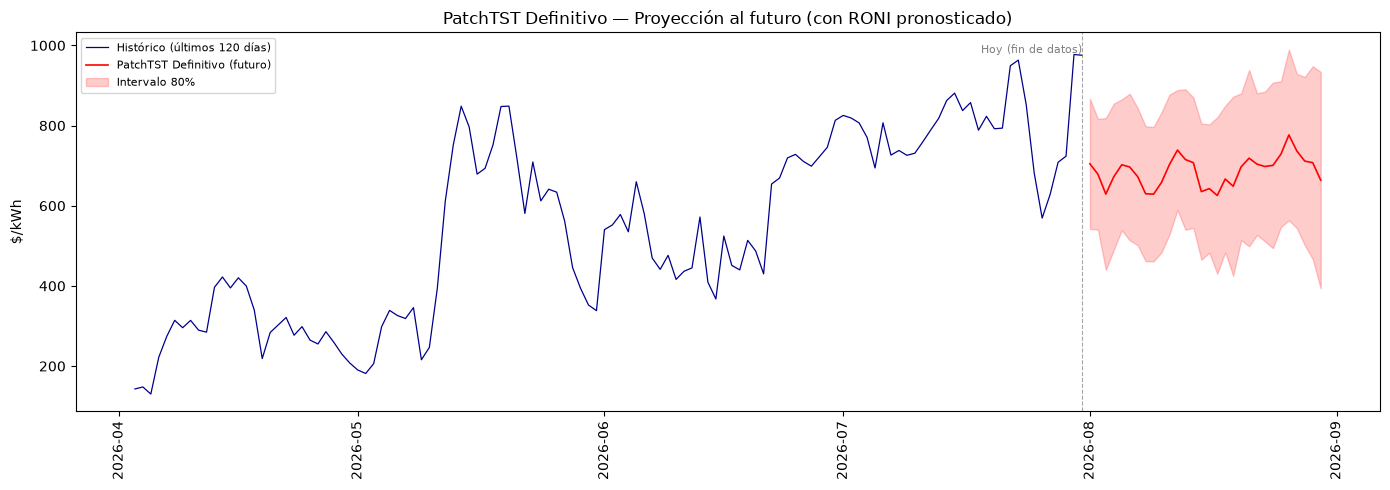

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

contexto_reciente = target_completo[-120:]
ax.plot(contexto_reciente.index, contexto_reciente.values, color='darkblue', linewidth=0.9, label='Histórico (últimos 120 días)')
ax.plot(fechas_futuras, forecast_futuro.mean, color='red', linewidth=1.2, label='PatchTST Definitivo (futuro)')
ax.fill_between(fechas_futuras, forecast_futuro.quantile(0.1), forecast_futuro.quantile(0.9), alpha=0.2, color='red', label='Intervalo 80%')

ax.axvline(target_completo.index[-1], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(target_completo.index[-1], ax.get_ylim()[1]*0.95, 'Hoy (fin de datos)', fontsize=8, color='gray', ha='right')

ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('PatchTST Definitivo — Proyección al futuro (con RONI pronosticado)')
plt.tight_layout()
plt.show()

In [16]:
ruta_modelo = raiz / 'models' / 'patchtst_definitivo'
ruta_modelo.mkdir(parents=True, exist_ok=True)

predictor_final.serialize(ruta_modelo)
joblib.dump(scaler_cov, raiz / 'models' / 'patchtst_definitivo_scaler.pkl')
print("Modelo definitivo guardado — próxima vez se puede cargar sin reentrenar:")
print("from gluonts.torch.model.predictor import PyTorchPredictor")
print("predictor_final = PyTorchPredictor.deserialize(raiz / 'models' / 'patchtst_definitivo')")

Modelo definitivo guardado — próxima vez se puede cargar sin reentrenar:
from gluonts.torch.model.predictor import PyTorchPredictor
predictor_final = PyTorchPredictor.deserialize(raiz / 'models' / 'patchtst_definitivo')
